In [2]:
'''
import sys
!{sys.executable} -m pip install kneed
'''

'\nimport sys\n!{sys.executable} -m pip install kneed\n'

In [3]:
'''
import kneed
print("kneed is installed and working")
'''

'\nimport kneed\nprint("kneed is installed and working")\n'

Calculating Elbow + Silhouette...
Optimal k (Silhouette): 2
Optimal k (Elbow/Kneedle): 6
Final chosen k: 6


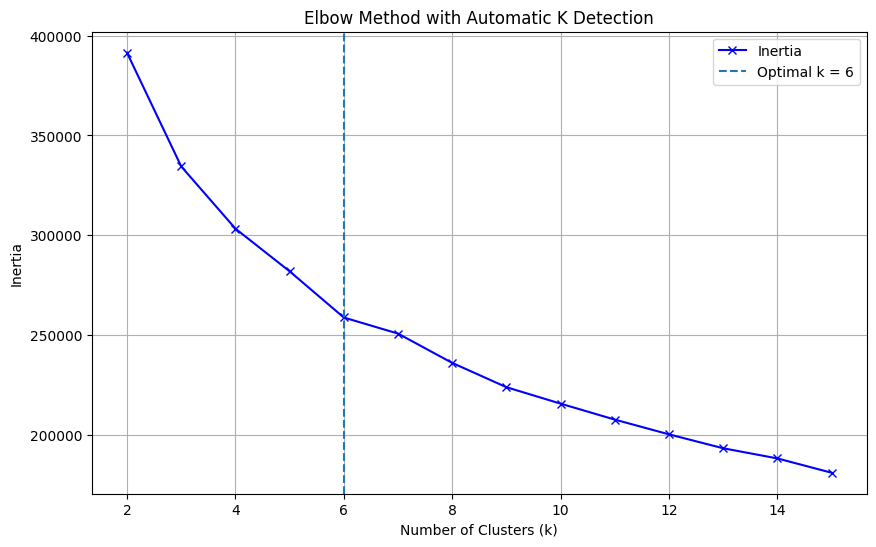

Final clustered dataset saved


In [4]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

# Try importing KneeLocator
try:
    from kneed import KneeLocator
    kneed_available = True
except ImportError:
    print("kneed not installed, will fallback to silhouette method")
    kneed_available = False

# 1. Load dataset
df = pd.read_csv('final_dance_dataset.csv')

# 2. Select features
features = [col for col in df.columns if any(axis in col for axis in ['x', 'y', 'z']) and 'frame' not in col]
X = df[features]

# 3. Scale data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 4. Elbow + Silhouette
print("Calculating Elbow + Silhouette...")
inertia = []
sil_scores = []
K_range = range(2, 16)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    
    inertia.append(km.inertia_)
    sil_scores.append(silhouette_score(X_scaled, labels))

# 5. Best k from silhouette
optimal_k_sil = K_range[sil_scores.index(max(sil_scores))]
print(f"Optimal k (Silhouette): {optimal_k_sil}")

# 6. Knee detection
optimal_k = None
if kneed_available:
    kneedle = KneeLocator(K_range, inertia, curve='convex', direction='decreasing')
    optimal_k = kneedle.knee
    print(f"Optimal k (Elbow/Kneedle): {optimal_k}")

# 7. Final decision
if optimal_k is None:
    print("Elbow failed -> using Silhouette")
    optimal_k = optimal_k_sil

# Ultimate fallback (very rare but safe)
if optimal_k is None:
    optimal_k = 6
    print("Both methods failed -> using default k=6")

print(f"Final chosen k: {optimal_k}")

# 8. Plot
plt.figure(figsize=(10, 6))
plt.plot(K_range, inertia, 'bx-', label='Inertia')

if optimal_k is not None:
    plt.axvline(x=optimal_k, linestyle='--', label=f'Optimal k = {optimal_k}')

plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method with Automatic K Detection')
plt.legend()
plt.grid(True)
plt.savefig('kmeans_elbow_plot.png')
plt.show()

# 9. Final clustering
final_model = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
df['cluster_id'] = final_model.fit_predict(X_scaled)

# 10. Save
df.to_csv('k-means_clusters_k_Silhouette.csv', index=False)
print("Final clustered dataset saved")

“Silhouette score suggested k=2, indicating two broadly separable groups, while the elbow method identified k=6, capturing finer-grained structure in pose variations. Given the complexity of human motion data, k=6 was selected to preserve meaningful intra-class diversity.”

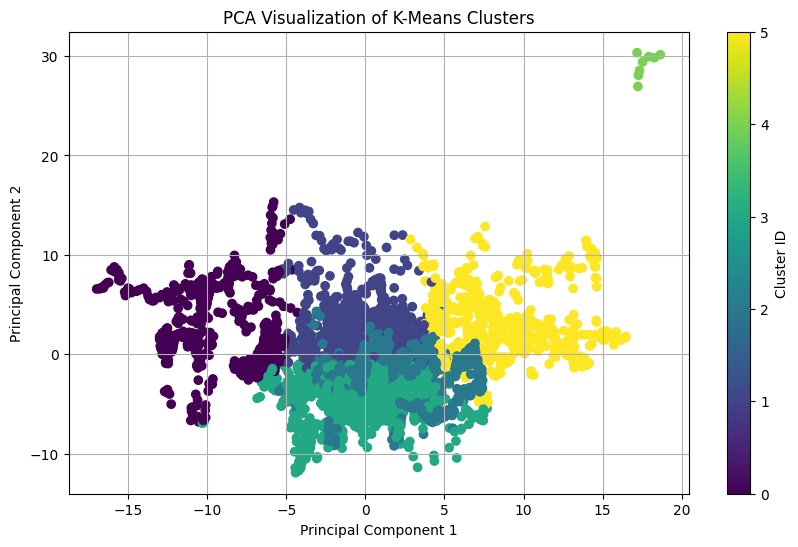

In [7]:
from sklearn.decomposition import PCA

# Reduce to 2D
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# Plot
plt.figure(figsize=(10, 6))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=df['cluster_id'])
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('PCA Visualization of K-Means Clusters')
plt.colorbar(scatter, label='Cluster ID')
plt.grid(True)
plt.savefig('pca_clusters.png')
plt.show()

Running t-SNE...


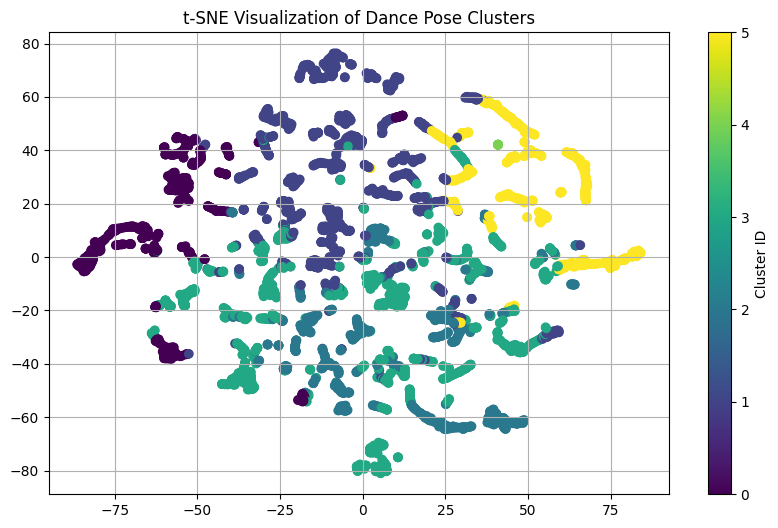

In [8]:
from sklearn.manifold import TSNE

print("Running t-SNE...")

tsne = TSNE(n_components=2, perplexity=30, random_state=42)
X_tsne = tsne.fit_transform(X_scaled)

# Plot
plt.figure(figsize=(10, 6))
scatter = plt.scatter(X_tsne[:, 0], X_tsne[:, 1], c=df['cluster_id'])
plt.title('t-SNE Visualization of Dance Pose Clusters')
plt.colorbar(scatter, label='Cluster ID')
plt.grid(True)
plt.savefig('tsne_clusters.png')
plt.show()